# First machine-learning baseline

The purpose of this notebook is not yet to build the best lifetime estimator. It is to establish reproducible reference results against which later feature engineering, neural networks, IRF-aware models, and improved datasets can be compared.

## Scientific question

For every simulated TCSPC histogram, the ML model receives the normalized photon-count distribution

```bash
X_normalized = X / X.sum(axis=1, keepdims=True)
```

and predicts the underlying fluorescence lifetime:

```bash
lifetime_predicted = model.predict(X_normalized)
```

The target is therefore:

```bash
y = lifetime_true
```

Normalization removes the overall signal scale and forces the model to learn primarily from the **shape of the decay curve**.

However, this also means that the model does not directly receive the total photon count. Photon count must therefore remain in the metadata so that we can determine how prediction accuracy deteriorates for noisy, low-count curves.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.base import RegressorMixin
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import (
    GradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    median_absolute_error,
    r2_score,
)
from sklearn.model_selection import train_test_split

from tcspc_toolkit.datasets import generate_dataset

In [2]:
time = np.linspace(
    0.0,
    20.0,
    256,
    dtype=np.float64,
)

dataset = generate_dataset(
    n_curves=10_000,
    time=time,
    lifetime_range=(0.5, 5.0),
    amplitude_range=(100.0, 2_000.0),
    background_range=(0.0, 20.0),
    photon_count_range=(1_000, 100_000),
    random_seed=42,
)

print("X shape:", dataset.X.shape)
print("y shape:", dataset.y.shape)
print("metadata shape:", dataset.metadata.shape)

X = dataset.X
y = dataset.y
metadata = dataset.metadata

print("X dtype:", X.dtype)
print("y dtype:", y.dtype)

X shape: (10000, 256)
y shape: (10000,)
metadata shape: (10000, 7)
X dtype: int64
y dtype: float64


In [3]:
photon_sums = X.sum(axis=1, keepdims=True)

if np.any(photon_sums == 0):
    raise ValueError(
        "Cannot normalize curves containing zero total photon counts."
    )

X_normalized = X / photon_sums

print(X_normalized.shape)
print(X_normalized.sum(axis=1)[:5])

assert np.allclose(
    X_normalized.sum(axis=1),
    1.0,
)

(10000, 256)
[1. 1. 1. 1. 1.]


## Why normalization matters

Suppose two curves have the same lifetime but different total photon counts:

```bash
curve_a = np.array([1000, 700, 500, 300])
curve_b = np.array([100, 70, 50, 30])
```

Their absolute values differ by a factor of ten, but their normalized shapes are identical. This prevents the ML model from incorrectly treating total signal strength as the main lifetime indicator.

At the same time, the lower-count curve would normally be noisier because of Poisson sampling. Thus, normalization removes the scale but does **not** remove the statistical consequences of low photon counts.

In [4]:
(
    X_train,
    X_test,
    y_train,
    y_test,
    metadata_train,
    metadata_test,
) = train_test_split(
    X_normalized,
    y,
    metadata,
    test_size=0.2,
    random_state=42,
)

print("Training curves:", X_train.shape)
print("Test curves:", X_test.shape)
print("Training targets:", y_train.shape)
print("Test targets:", y_test.shape)

Training curves: (8000, 256)
Test curves: (2000, 256)
Training targets: (8000,)
Test targets: (2000,)


In [5]:
mean_baseline = DummyRegressor(
    strategy="mean",
)

mean_baseline.fit(
    X_train,
    y_train,
)

y_pred_mean = mean_baseline.predict(X_test)

y_train_mean = np.mean(y_train)

y_pred_mean_manual = np.full(
    shape=y_test.shape,
    fill_value=y_train_mean,
    dtype=np.float64,
)

assert np.allclose(
    y_pred_mean,
    y_pred_mean_manual,
)

In [6]:
ridge = Ridge(
    alpha=1.0,
)

ridge.fit(
    X_train,
    y_train,
)

y_pred_ridge = ridge.predict(X_test)

print(ridge.coef_.shape)

(256,)


In [7]:
random_forest = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)

random_forest.fit(
    X_train,
    y_train,
)

y_pred_random_forest = random_forest.predict(X_test)

In [8]:
gradient_boosting = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
)

gradient_boosting.fit(
    X_train,
    y_train,
)

y_pred_gradient_boosting = gradient_boosting.predict(
    X_test
)

In [9]:
def absolute_relative_error(
    y_true: np.ndarray,
    y_pred: np.ndarray,
) -> np.ndarray:
    """Return absolute relative error for each prediction."""
    if y_true.shape != y_pred.shape:
        raise ValueError(
            "y_true and y_pred must have identical shapes."
        )

    if np.any(y_true == 0):
        raise ValueError(
            "Relative error is undefined for zero target values."
        )

    return np.abs(y_pred - y_true) / np.abs(y_true)

In [10]:
def evaluate_predictions(
    model_name: str,
    y_true: np.ndarray,
    y_pred: np.ndarray,
) -> dict[str, float]:
    """Calculate regression metrics for lifetime predictions."""
    relative_errors = absolute_relative_error(
        y_true,
        y_pred,
    )

    return {
        "model": model_name,
        "mae_ns": mean_absolute_error(
            y_true,
            y_pred,
        ),
        "median_absolute_error_ns": median_absolute_error(
            y_true,
            y_pred,
        ),
        "mean_relative_error": np.mean(relative_errors),
        "median_relative_error": np.median(relative_errors),
        "r2": r2_score(
            y_true,
            y_pred,
        ),
    }

In [11]:
predictions = {
    "Mean baseline": y_pred_mean,
    "Ridge": y_pred_ridge,
    "Random Forest": y_pred_random_forest,
    "Gradient Boosting": y_pred_gradient_boosting,
}

evaluation_rows = []

for model_name, y_pred in predictions.items():
    metrics = evaluate_predictions(
        model_name=model_name,
        y_true=y_test,
        y_pred=y_pred,
    )
    evaluation_rows.append(metrics)


results = pd.DataFrame(evaluation_rows)

results = results.sort_values(
    by="mae_ns",
    ascending=True,
).reset_index(drop=True)

results

results_display = results.copy()

results_display["mean_relative_error_percent"] = (
    100.0 * results_display["mean_relative_error"]
)

results_display["median_relative_error_percent"] = (
    100.0 * results_display["median_relative_error"]
)

results_display[
    [
        "model",
        "mae_ns",
        "median_absolute_error_ns",
        "mean_relative_error_percent",
        "median_relative_error_percent",
        "r2",
    ]
]

,model,mae_ns,median_absolute_error_ns,mean_relative_error_percent,median_relative_error_percent,r2
0,Random Forest,0.054176,0.026926,1.866435,1.190423,0.993852
1,Gradient Boosting,0.058001,0.036954,2.272810,1.661831,0.994992
2,Ridge,0.403651,0.319353,22.393297,12.825313,0.841864
3,Mean baseline,1.139514,1.136433,70.381730,36.196714,-0.001866


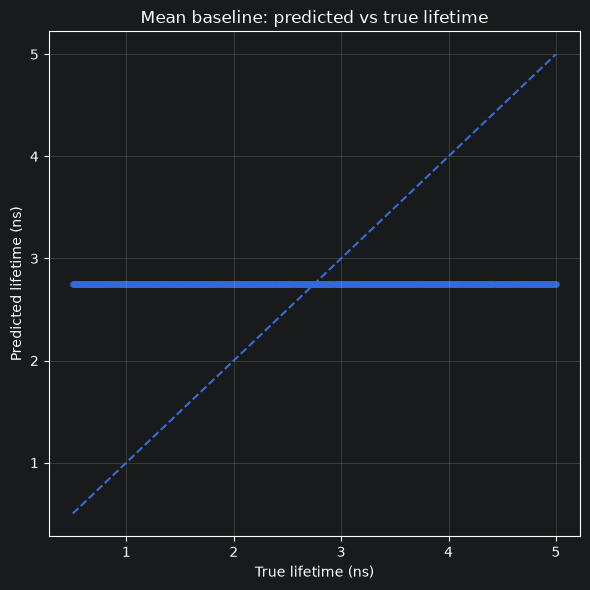

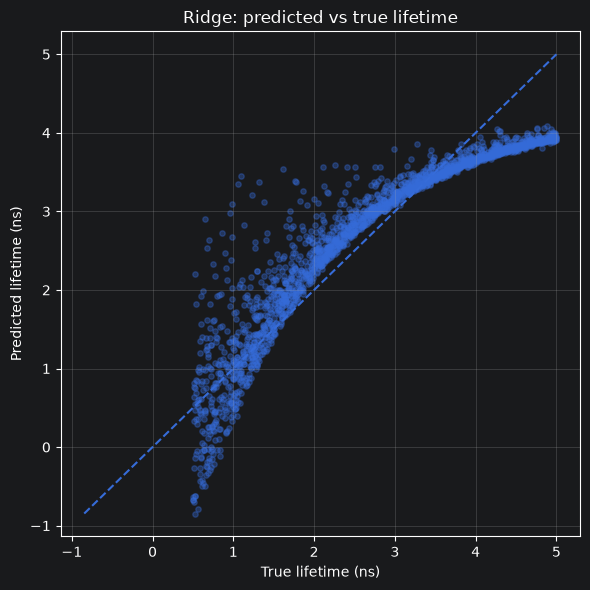

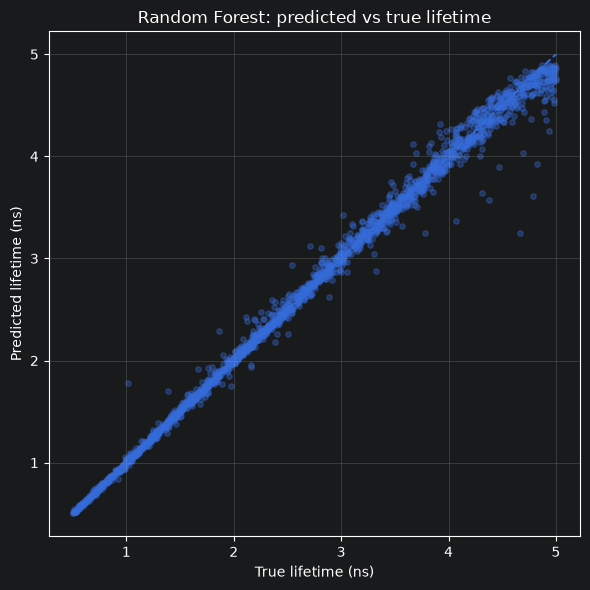

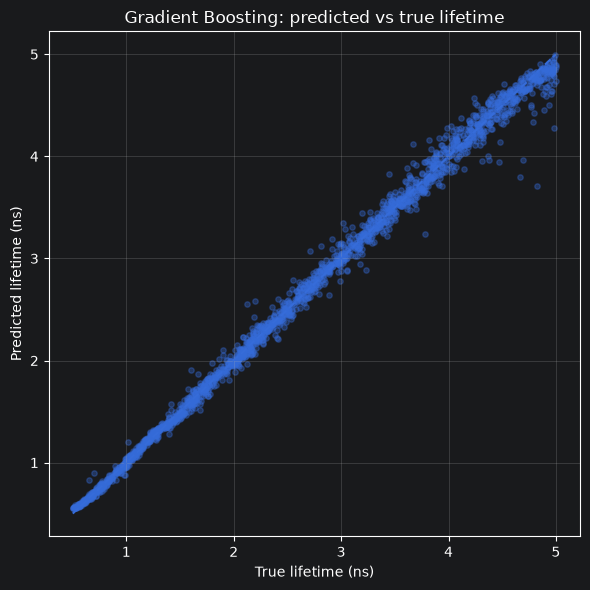

In [12]:
for model_name, y_pred in predictions.items():
    plt.figure(figsize=(6, 6))

    plt.scatter(
        y_test,
        y_pred,
        alpha=0.35,
        s=15,
    )

    minimum_lifetime = min(
        np.min(y_test),
        np.min(y_pred),
    )
    maximum_lifetime = max(
        np.max(y_test),
        np.max(y_pred),
    )

    plt.plot(
        [minimum_lifetime, maximum_lifetime],
        [minimum_lifetime, maximum_lifetime],
        linestyle="--",
    )

    plt.xlabel("True lifetime (ns)")
    plt.ylabel("Predicted lifetime (ns)")
    plt.title(f"{model_name}: predicted vs true lifetime")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

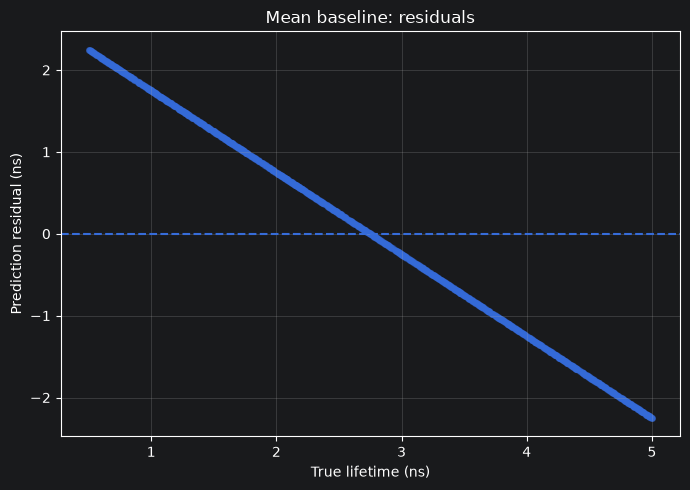

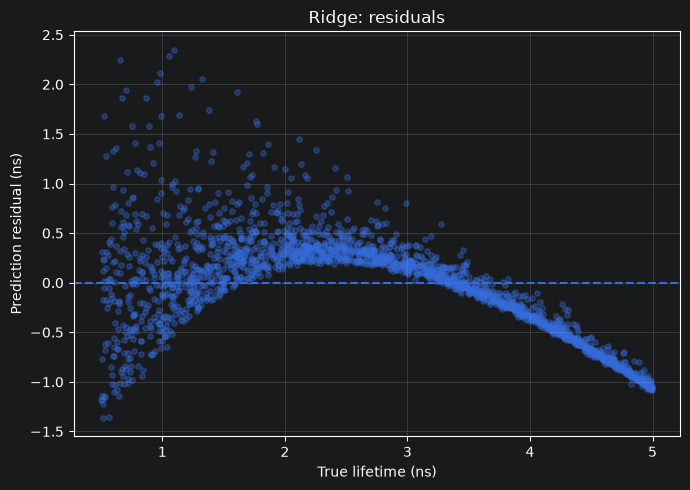

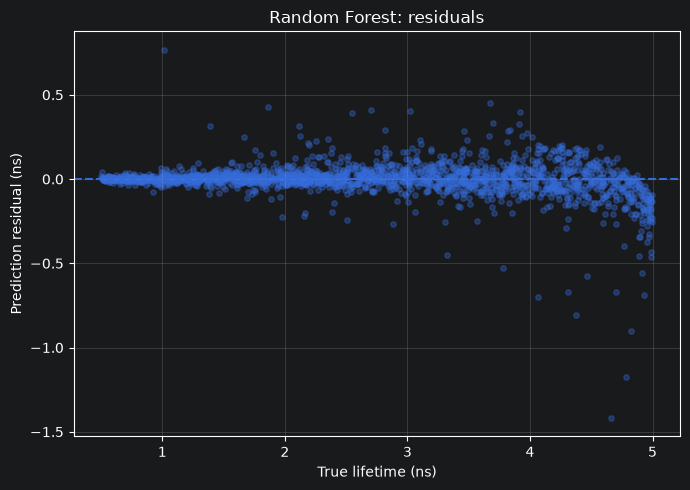

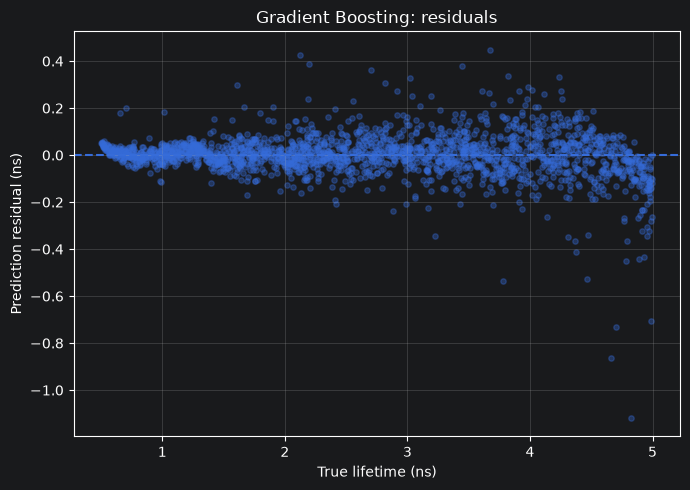

In [13]:
for model_name, y_pred in predictions.items():
    residuals = y_pred - y_test

    plt.figure(figsize=(7, 5))

    plt.scatter(
        y_test,
        residuals,
        alpha=0.35,
        s=15,
    )

    plt.axhline(
        0.0,
        linestyle="--",
    )

    plt.xlabel("True lifetime (ns)")
    plt.ylabel("Prediction residual (ns)")
    plt.title(f"{model_name}: residuals")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [14]:
test_results = metadata_test.copy()

test_results["lifetime_true"] = y_test

for model_name, y_pred in predictions.items():
    safe_name = (
        model_name.lower()
        .replace(" ", "_")
    )

    test_results[f"{safe_name}_prediction"] = y_pred

    test_results[f"{safe_name}_absolute_error"] = np.abs(
        y_pred - y_test
    )

    test_results[f"{safe_name}_relative_error"] = (
        np.abs(y_pred - y_test) / y_test
    )

test_results.head()

,curve_id,lifetime_true,amplitude_true,background_true,photon_count_target,photon_count_expected,photon_count,mean_baseline_prediction,mean_baseline_absolute_error,mean_baseline_relative_error,ridge_prediction,ridge_absolute_error,ridge_relative_error,random_forest_prediction,random_forest_absolute_error,random_forest_relative_error,gradient_boosting_prediction,gradient_boosting_absolute_error,gradient_boosting_relative_error
6252,6252,2.432265,1367.987331,6.477951,44758,44758.0,44857,2.748341,0.316075,0.129951,2.696059,0.263793,0.108456,2.418861,0.013404,0.005511,2.387037,0.045228,0.018595
4684,4684,4.986092,63.101676,0.659815,4140,4140.0,4076,2.748341,2.237752,0.448799,3.918447,1.067646,0.214125,4.553245,0.432847,0.086811,4.280571,0.705521,0.141498
1731,1731,0.728963,1607.016592,32.746173,24137,24137.0,24038,2.748341,2.019377,2.770204,1.298771,0.569807,0.781668,0.762981,0.034018,0.046666,0.764121,0.035158,0.048230
4742,4742,4.006123,439.389374,4.579377,23685,23685.0,23888,2.748341,1.257783,0.313965,3.644987,0.361136,0.090146,3.934936,0.071187,0.017770,4.001513,0.004610,0.001151
4521,4521,2.362099,1553.216782,15.534784,51526,51526.0,51195,2.748341,0.386241,0.163516,2.706443,0.344344,0.145779,2.345201,0.016898,0.007154,2.372083,0.009984,0.004227


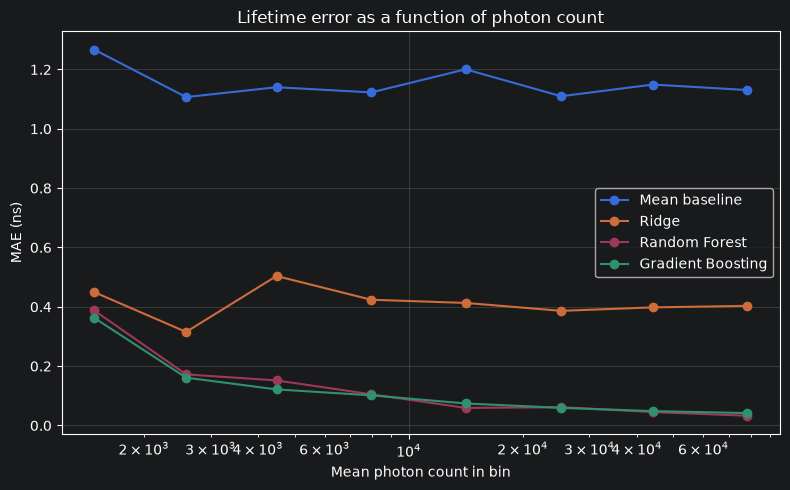

In [15]:
photon_bin_edges = np.logspace(
    np.log10(test_results["photon_count"].min()),
    np.log10(test_results["photon_count"].max()),
    9,
)

test_results["photon_count_bin"] = pd.cut(
    test_results["photon_count"],
    bins=photon_bin_edges,
    include_lowest=True,
)

photon_count_rows = []

for model_name in predictions:
    safe_name = (
        model_name.lower()
        .replace(" ", "_")
    )

    grouped = (
        test_results
        .groupby(
            "photon_count_bin",
            observed=True,
        )
        .agg(
            photon_count_mean=(
                "photon_count",
                "mean",
            ),
            mae_ns=(
                f"{safe_name}_absolute_error",
                "mean",
            ),
            median_absolute_error_ns=(
                f"{safe_name}_absolute_error",
                "median",
            ),
            number_of_curves=(
                "photon_count",
                "size",
            ),
        )
        .reset_index()
    )

    grouped["model"] = model_name
    photon_count_rows.append(grouped)

error_by_photon_count = pd.concat(
    photon_count_rows,
    ignore_index=True,
)

error_by_photon_count.head()

plt.figure(figsize=(8, 5))

for model_name in predictions:
    model_data = error_by_photon_count[
        error_by_photon_count["model"] == model_name
    ]

    plt.plot(
        model_data["photon_count_mean"],
        model_data["mae_ns"],
        marker="o",
        label=model_name,
    )

plt.xscale("log")
plt.xlabel("Mean photon count in bin")
plt.ylabel("MAE (ns)")
plt.title("Lifetime error as a function of photon count")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

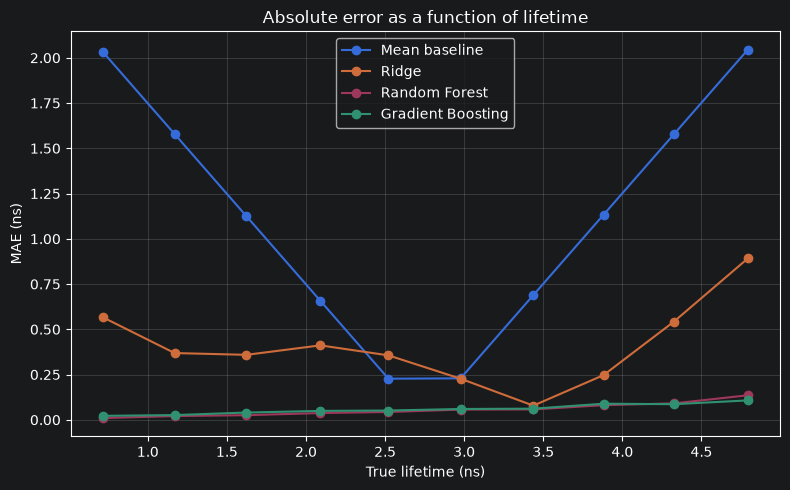

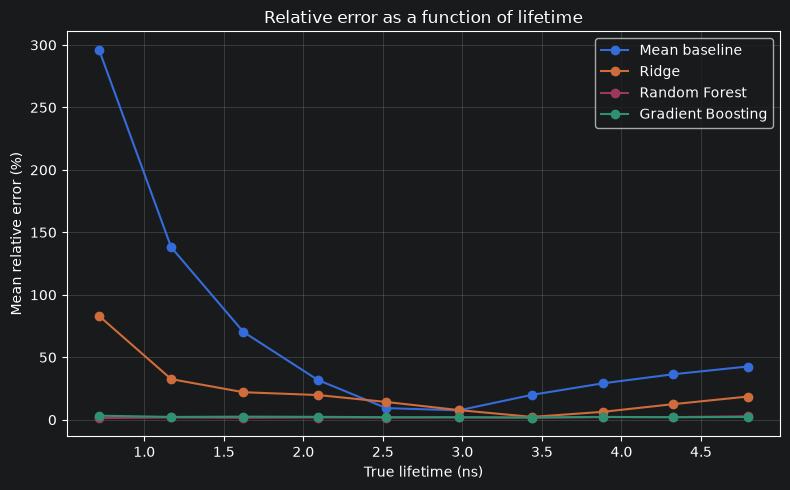

In [16]:
lifetime_bin_edges = np.linspace(
    y_test.min(),
    y_test.max(),
    11,
)

test_results["lifetime_bin"] = pd.cut(
    test_results["lifetime_true"],
    bins=lifetime_bin_edges,
    include_lowest=True,
)

lifetime_rows = []

for model_name in predictions:
    safe_name = (
        model_name.lower()
        .replace(" ", "_")
    )

    grouped = (
        test_results
        .groupby(
            "lifetime_bin",
            observed=True,
        )
        .agg(
            lifetime_mean=(
                "lifetime_true",
                "mean",
            ),
            mae_ns=(
                f"{safe_name}_absolute_error",
                "mean",
            ),
            median_absolute_error_ns=(
                f"{safe_name}_absolute_error",
                "median",
            ),
            mean_relative_error=(
                f"{safe_name}_relative_error",
                "mean",
            ),
            number_of_curves=(
                "lifetime_true",
                "size",
            ),
        )
        .reset_index()
    )

    grouped["model"] = model_name
    lifetime_rows.append(grouped)

error_by_lifetime = pd.concat(
    lifetime_rows,
    ignore_index=True,
)

plt.figure(figsize=(8, 5))

for model_name in predictions:
    model_data = error_by_lifetime[
        error_by_lifetime["model"] == model_name
    ]

    plt.plot(
        model_data["lifetime_mean"],
        model_data["mae_ns"],
        marker="o",
        label=model_name,
    )

plt.xlabel("True lifetime (ns)")
plt.ylabel("MAE (ns)")
plt.title("Absolute error as a function of lifetime")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))

for model_name in predictions:
    model_data = error_by_lifetime[
        error_by_lifetime["model"] == model_name
    ]

    plt.plot(
        model_data["lifetime_mean"],
        100.0 * model_data["mean_relative_error"],
        marker="o",
        label=model_name,
    )

plt.xlabel("True lifetime (ns)")
plt.ylabel("Mean relative error (%)")
plt.title("Relative error as a function of lifetime")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Note

Because every histogram is normalized independently, the models do not receive total photon count as an input feature. Photon count is retained only for performance stratification. Consequently, differences in prediction quality across photon-count ranges arise from differences in histogram noise rather than direct access to the photon-count metadata.

This makes the baseline scientifically interpretable and prepares the next comparison: **normalized raw bins versus normalized bins plus engineered features**, such as total photon count, temporal moments, peak position, tail integrals, and background estimates.